# An electric field is more than its transverse components
We specify Ex and Ey on a physical plane, leaving Ez unknown. Completion
chooses a propagation branch and enforces k·E=0. A supplied zero Ez is a
physical assertion, not the same state as an unspecified Ez.

Run from the repository root or any directory inside this checkout, after
`python -m pip install -e '.[notebooks,validation,nufft]'`.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(root))
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
import numpy as np
from vecdiff import CartesianGrid, PlaneDomain, TransverseElectricField, ElectricField
grid = CartesianGrid.from_spacing(.8, 32)
x, y = grid.xy
field = TransverseElectricField(np.exp(-(x*x+y*y)/9), np.zeros(grid.shape), grid, PlaneDomain())
assert isinstance(field, ElectricField) and field.Ez is None
completed = field.complete()
assert completed.Ez is not None

## Propagation, flux, and reversibility
The workflow below uses a propagating-only lattice: every sampled k is below
the light cone. Thus reverse propagation is well conditioned. On a finer
grid, reversing evanescent decay amplifies roundoff exponentially; it is not
a stable reconstruction of missing near-field data.

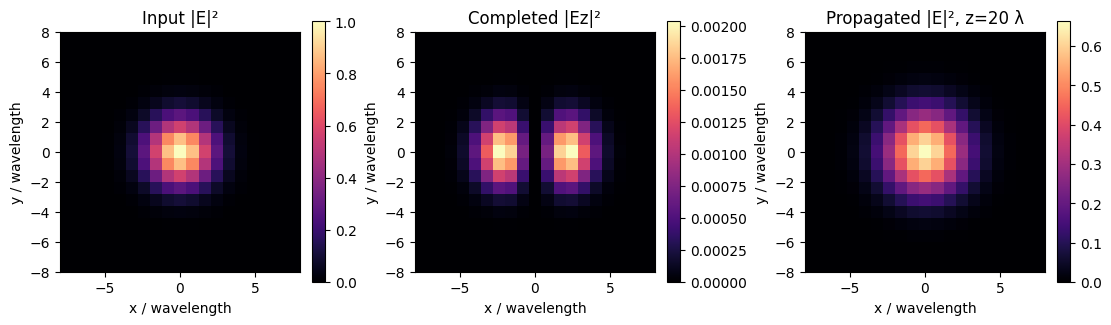

{'purpose': 'Unknown Ez is completed through k·E=0, not set to zero.',
 'assumptions': 'Homogeneous medium; periodic, propagating-only sampled model. Not a hard-aperture model.',
 'reversal_relative_error': 6.741367166899516e-16,
 'normal_flux_relative_error': 2.220446049250313e-16,
 'longitudinal_norm_fraction': 0.002838629160888542}

In [2]:
from examples.field_propagation import run
figure, report = run()
display(figure)
plt.close(figure)
{key: value for key, value in report.items() if key != "parameters"}

| Quantity | Interpretation |
| --- | --- |
| Longitudinal norm fraction | Electric-component content, not a power fraction |
| Normal flux error | Poynting flux integrated over the same periodic window |
| Reversal error | Numerical reversibility within the selected spectral model |

To study a smaller waist, refine both sampling and the physical window and
explicitly decide whether near fields are required. No hidden cutoff is applied.